In [74]:
import pandas as pd 
import matplotlib.pyplot as ply
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

In [75]:
df = pd.read_csv("dataset.csv")
display(df.shape)


(114000, 21)

In [76]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [78]:
display(df[df.isnull().any(axis=1)])
df.dropna(inplace=True)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [79]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,56999.421925,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,32909.243463,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.500000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,56999.000000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.500000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [80]:
df.duplicated().sum()

np.int64(0)

## Dropping the non relative columns

In [81]:
music = df.drop(columns = ["Unnamed: 0","explicit","key","mode","time_signature"])

In [82]:
music.head(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,acoustic


In [83]:
music.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113999 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        113999 non-null  int64  
 5   duration_ms       113999 non-null  int64  
 6   danceability      113999 non-null  float64
 7   energy            113999 non-null  float64
 8   loudness          113999 non-null  float64
 9   speechiness       113999 non-null  float64
 10  acousticness      113999 non-null  float64
 11  instrumentalness  113999 non-null  float64
 12  liveness          113999 non-null  float64
 13  valence           113999 non-null  float64
 14  tempo             113999 non-null  float64
 15  track_genre       113999 non-null  object 
dtypes: float64(9), int64(2), 

## Removing the duplicates

In [84]:
display(music.duplicated().sum()) 
music = music.drop_duplicates()
music.shape

np.int64(450)

(113549, 16)

In [85]:
display(music['track_id'].duplicated().sum())
music = music.drop_duplicates(subset = 'track_id', keep = 'first')
music.shape

np.int64(23809)

(89740, 16)

In [86]:
display(music.duplicated(subset = ['track_name','artists']).sum())
music = music.drop_duplicates(subset = ['track_name','artists'], keep = 'first')
music.shape

np.int64(8397)

(81343, 16)

In [87]:
display(music.duplicated(subset = ['track_name','album_name']).sum())
music = music.drop_duplicates(subset = ['track_name','album_name'], keep = 'first')
music.shape

np.int64(1064)

(80279, 16)

## Converting 114 genre to 11 genre

In [88]:
genre_mapping = {'pop': 'Pop','j-pop': 'Pop','k-pop': 'Pop','mandopop': 'Pop','cantopop': 'Pop','indie-pop': 'Pop','power-pop': 'Pop','pop-film': 'Pop','synth-pop': 'Pop','j-idol': 'Pop',
                 'rock': 'Rock','alt-rock': 'Rock','alternative': 'Rock','black-metal': 'Rock','death-metal': 'Rock','emo': 'Rock','goth': 'Rock','grindcore': 'Rock','grunge': 'Rock','hard-rock': 'Rock','hardcore': 'Rock','heavy-metal': 'Rock','j-rock': 'Rock','metal': 'Rock','metalcore': 'Rock','punk': 'Rock','punk-rock': 'Rock','psych-rock': 'Rock','rock-n-roll': 'Rock','rockabilly': 'Rock','indie': 'Rock','rock': 'Rock','alt-rock': 'Rock','alternative': 'Rock','black-metal': 'Rock','death-metal': 'Rock','emo': 'Rock','goth': 'Rock','grindcore': 'Rock','grunge': 'Rock','hard-rock': 'Rock','hardcore': 'Rock','heavy-metal': 'Rock','j-rock': 'Rock','metal': 'Rock','metalcore': 'Rock','punk': 'Rock','punk-rock': 'Rock','psych-rock': 'Rock','rock-n-roll': 'Rock','rockabilly': 'Rock','indie': 'Rock',
                 'electronic': 'Dance','ambient': 'Dance','breakbeat': 'Dance','chicago-house': 'Dance','chill': 'Dance','club': 'Dance','dance': 'Dance','deep-house': 'Dance','detroit-techno': 'Dance','disco': 'Dance','drum-and-bass': 'Dance','dub': 'Dance','dubstep': 'Dance','edm': 'Dance','electro': 'Dance','garage': 'Dance','hardstyle': 'Dance','house': 'Dance','idm': 'Dance','j-dance': 'Dance','minimal-techno': 'Dance','progressive-house': 'Dance','techno': 'Dance','trance': 'Dance','trip-hop': 'Dance','party': 'Dance',
                 'hip-hop': 'Hip-Hop','r-n-b': 'Hip-Hop',
                 'acoustic': 'Folk','bluegrass': 'Folk','country': 'Folk','folk': 'Folk','singer-songwriter': 'Folk','songwriter': 'Folk','honky-tonk': 'Folk','guitar': 'Folk','piano': 'Folk',
                 'blues': 'Funk','funk': 'Funk','groove': 'Funk','jazz': 'Funk','soul': 'Funk',
                 'classical': 'Classical','opera': 'Classical',
                 'afrobeat': 'Regional','brazil': 'Regional','british': 'Regional','dancehall': 'Regional','forro': 'Regional','french': 'Regional','german': 'Regional','indian': 'Regional','iranian': 'Regional','latin': 'Regional','latino': 'Regional','malay': 'Regional','mpb': 'Regional','pagode': 'Regional','reggae': 'Regional','reggaeton': 'Regional','salsa': 'Regional','samba': 'Regional','sertanejo': 'Regional','ska': 'Regional','spanish': 'Regional','swedish': 'Regional','tango': 'Regional','turkish': 'Regional','world-music': 'Regional',
                 'anime': 'Mood','children': 'Mood','comedy': 'Mood','disney': 'Mood','gospel': 'Mood','happy': 'Mood','kids': 'Mood','new-age': 'Mood','show-tunes': 'Mood','sleep': 'Mood','study': 'Mood','industrial': 'Mood', 
                 'romance': 'Romance',
                 'sad': 'Sad'
}
music['track_genre'] = music['track_genre'].map(genre_mapping)
music['track_genre'].value_counts()

track_genre
Dance        18738
Regional     18317
Rock         12893
Mood         10803
Pop           7223
Folk          5964
Funk          2358
Classical     1560
Hip-Hop       1077
Romance        856
Sad            490
Name: count, dtype: int64

## Converting ms to minutes


In [89]:
music['duration_min'] = music['duration_ms'] / 60000
music['duration_min'] = music['duration_min'].round(2)
music.drop(columns = ['duration_ms'], inplace = True)

## SCALARIZING THE FEATURES
**tempo, loudness and popularity need scalability**

<Axes: xlabel='loudness', ylabel='Density'>

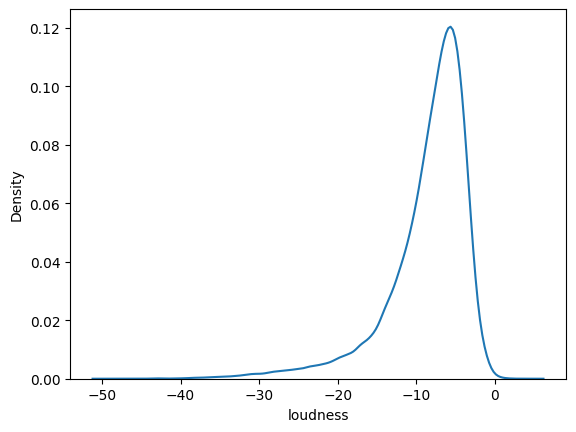

In [90]:
sns.kdeplot(data = music, x = 'loudness')

<Axes: xlabel='tempo', ylabel='Density'>

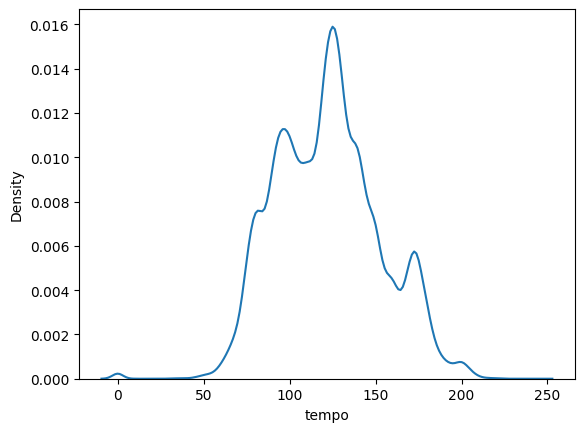

In [91]:
sns.kdeplot(data = music, x = 'tempo')

In [92]:
minmax = MinMaxScaler()
scaled_features = ['loudness','popularity']
for column in scaled_features:
    music[column] = minmax.fit_transform(music[[column]])

In [93]:
scaler = StandardScaler()
scaled_features1 = ['tempo']
for column in scaled_features1:
    music[column] = scaler.fit_transform(music[[column]])

In [94]:
music.head()

,track_id,artists,album_name,track_name,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,0.73,0.676,0.4610,0.791392,0.1430,0.0322,0.000001,0.3580,0.715,-1.134079,Folk,3.84
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,0.55,0.420,0.1660,0.597377,0.0763,0.9240,0.000006,0.1010,0.267,-1.479836,Folk,2.49
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,0.57,0.438,0.3590,0.736123,0.0557,0.2100,0.000000,0.1170,0.120,-1.518198,Folk,3.51
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,0.71,0.266,0.0596,0.573701,0.0363,0.9050,0.000071,0.1320,0.143,1.976774,Folk,3.37
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,0.82,0.618,0.4430,0.737103,0.0526,0.4690,0.000000,0.0829,0.167,-0.072006,Folk,3.31


## Dividing the features into numeric for cosine similarity and metadata

In [95]:
numeric_features = []
metadata = []
for column in music.columns:
    if music[column].dtype != 'object':
        if column in ['duration_min','popularity']:
            continue
        numeric_features.append(column)
    else:
        metadata.append(column)
metadata.append('duration_min')
metadata.append('popularity')

display(numeric_features, metadata)

['danceability',
 'energy',
 'loudness',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo']

['track_id',
 'artists',
 'album_name',
 'track_name',
 'track_genre',
 'duration_min',
 'popularity']

## Reducing dimensionality using PCA

In [96]:
pca = PCA(n_components=5)
pca_numeric_features = pca.fit_transform(music[numeric_features])
explained_variance = pca.explained_variance_ratio_
total_variance = explained_variance.sum() 

print("Variance per component:", explained_variance)
print("Total variance:", total_variance)

Variance per component: [0.69612505 0.1165376  0.07894604 0.04213452 0.02967308]
Total variance: 0.963416288876361


## Updating the dataframe with PCA components

In [97]:
pca_features_df = pd.DataFrame(data=pca_numeric_features, columns=['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5'])
music.reset_index(drop=True, inplace=True)
music = pd.concat([music, pca_features_df], axis=1)
for column in numeric_features:
    music.drop(column, axis=1, inplace=True)
music.head()

,track_id,artists,album_name,track_name,popularity,track_genre,duration_min,PCA1,PCA2,PCA3,PCA4,PCA5
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,0.73,Folk,3.84,-1.098453,-0.432171,-0.093874,0.093762,0.005295
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,0.55,Folk,2.49,-1.563205,0.468256,-0.401480,-0.206204,-0.147380
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,0.57,Folk,3.51,-1.522248,-0.075269,0.057514,-0.371287,-0.287205
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,0.71,Folk,3.37,1.853886,0.992377,-0.473297,-0.369771,-0.169432
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,0.82,Folk,3.31,-0.103474,0.185433,-0.143254,-0.240847,-0.248420


In [98]:
music.to_csv("music_processed.csv", index=False)

## Adding image and preview links to the main dataframe

In [99]:
df1 = pd.read_csv('Music.csv')
df1.head()

,name,artist,spotify_id,preview,img,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,acousticness_artist,danceability_artist,energy_artist,instrumentalness_artist,liveness_artist,speechiness_artist,valence_artist
0,Mood (feat. iann dior),24kGoldn,3tjFYV6RSFtuktYl3ZtYcq,https://p.scdn.co/mp3-preview/45cb08fdb67744ab...,https://i.scdn.co/image/ab67616d0000b273ff8c98...,0.700,0.722,-3.558,0.0369,0.22100,0.000000,0.2720,0.756,0.118269,0.731588,0.681235,0.000002,0.160000,0.123765,0.566824
1,Blinding Lights,The Weeknd,0VjIjW4GlUZAMYd2vXMi3b,NaN,https://i.scdn.co/image/ab67616d0000b2738863bc...,0.514,0.730,-5.934,0.0598,0.00146,0.000095,0.0897,0.334,0.271439,0.574808,0.607873,0.010594,0.201728,0.086811,0.305189
2,Dynamite,BTS,0t1kP63rueHleOhQkYSXFY,https://p.scdn.co/mp3-preview/a707728846c105f4...,https://i.scdn.co/image/ab67616d0000b273755995...,0.746,0.765,-4.410,0.0993,0.01120,0.000000,0.0936,0.737,0.099350,0.614798,0.786452,0.000044,0.202608,0.128515,0.533369
3,ROCKSTAR (feat. Roddy Ricch),DaBaby,7ytR5pFWmSjzHJIeQkgog4,NaN,https://i.scdn.co/image/ab67616d0000b27320e08c...,0.746,0.690,-7.956,0.1640,0.24700,0.000000,0.1010,0.497,0.093113,0.829283,0.657626,0.000002,0.170425,0.284725,0.629374
4,For The Night (feat. Lil Baby & DaBaby),Pop Smoke,0PvFJmanyNQMseIFrU708S,NaN,https://i.scdn.co/image/ab67616d0000b27377ada0...,0.823,0.586,-6.606,0.2000,0.11400,0.000000,0.1930,0.347,0.191520,0.675143,0.702686,0.000194,0.247669,0.280103,0.490229


In [100]:
df1.drop_duplicates(subset='spotify_id',keep='first',inplace=True)
display(df1.duplicated(subset=['img', 'preview']).sum())
df1.drop_duplicates(subset=['img', 'preview'], keep='first', inplace=True)

np.int64(35935)

In [101]:
df1['track_id'] = df1['spotify_id']
columns_to_add = ['track_id', 'preview', 'img']
df_subset = df1[columns_to_add]
df_subset.head()

,track_id,preview,img
0,3tjFYV6RSFtuktYl3ZtYcq,https://p.scdn.co/mp3-preview/45cb08fdb67744ab...,https://i.scdn.co/image/ab67616d0000b273ff8c98...
1,0VjIjW4GlUZAMYd2vXMi3b,NaN,https://i.scdn.co/image/ab67616d0000b2738863bc...
2,0t1kP63rueHleOhQkYSXFY,https://p.scdn.co/mp3-preview/a707728846c105f4...,https://i.scdn.co/image/ab67616d0000b273755995...
3,7ytR5pFWmSjzHJIeQkgog4,NaN,https://i.scdn.co/image/ab67616d0000b27320e08c...
4,0PvFJmanyNQMseIFrU708S,NaN,https://i.scdn.co/image/ab67616d0000b27377ada0...


In [102]:
merged_df = pd.merge(music, df_subset, on='track_id', how='left')
merged_df.head()

,track_id,artists,album_name,track_name,popularity,track_genre,duration_min,PCA1,PCA2,PCA3,PCA4,PCA5,preview,img
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,0.73,Folk,3.84,-1.098453,-0.432171,-0.093874,0.093762,0.005295,NaN,NaN
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,0.55,Folk,2.49,-1.563205,0.468256,-0.401480,-0.206204,-0.147380,NaN,NaN
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,0.57,Folk,3.51,-1.522248,-0.075269,0.057514,-0.371287,-0.287205,NaN,NaN
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,0.71,Folk,3.37,1.853886,0.992377,-0.473297,-0.369771,-0.169432,NaN,NaN
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,0.82,Folk,3.31,-0.103474,0.185433,-0.143254,-0.240847,-0.248420,NaN,https://i.scdn.co/image/ab67616d0000b273c60473...


In [103]:
merged_df.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
track_genre         0
duration_min        0
PCA1                0
PCA2                0
PCA3                0
PCA4                0
PCA5                0
preview         77875
img             76988
dtype: int64

In [104]:
rows_with_links = merged_df.dropna(subset=['img', 'preview'], how='any')
df_no_string_placeholder = rows_with_links[rows_with_links['img'] != 'no']
song_list = df_no_string_placeholder[['artists','album_name','track_name']]
song_list.head()

,artists,album_name,track_name
6,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something
7,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours
8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky
15,Landon Pigg,The Boy Who Never,Falling in Love at a Coffee Shop
36,Andrew Belle,Black Bear,Pieces


In [105]:
rows_with_links.shape,df_no_string_placeholder.shape

((2404, 14), (2404, 14))

In [106]:
import random

df_target = merged_df 
df_source = df1

IMAGE_COL = 'img'
SONG_COL = 'preview' 

def fill_missing_urls(df_target, df_source, col_name):
       
    valid_url_pool = df_source[col_name].dropna().loc[lambda x: x != 'no'].tolist()

    mask_nan = pd.isnull(df_target[col_name])
    mask_no = df_target[col_name] == 'no'
    
    all_null_indices = df_target[mask_nan | mask_no].index
    
    num_to_fill = len(all_null_indices)
    
    random_choices = random.choices(valid_url_pool, k=num_to_fill)

    df_target.loc[all_null_indices, col_name] = random_choices
    
    print(f"Filled {num_to_fill} missing values in '{col_name}' with random URLs.")


fill_missing_urls(df_target, df_source, IMAGE_COL)

fill_missing_urls(df_target, df_source, SONG_COL)

Filled 76988 missing values in 'img' with random URLs.
Filled 77875 missing values in 'preview' with random URLs.


In [107]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80279 entries, 0 to 80278
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   track_id      80279 non-null  object 
 1   artists       80279 non-null  object 
 2   album_name    80279 non-null  object 
 3   track_name    80279 non-null  object 
 4   popularity    80279 non-null  float64
 5   track_genre   80279 non-null  object 
 6   duration_min  80279 non-null  float64
 7   PCA1          80279 non-null  float64
 8   PCA2          80279 non-null  float64
 9   PCA3          80279 non-null  float64
 10  PCA4          80279 non-null  float64
 11  PCA5          80279 non-null  float64
 12  preview       80279 non-null  object 
 13  img           80279 non-null  object 
dtypes: float64(7), object(7)
memory usage: 8.6+ MB


In [108]:
merged_df[merged_df.duplicated(subset=['track_id'])].shape,merged_df[merged_df.duplicated(subset=['img'])].shape,merged_df[merged_df.duplicated(subset=['preview'])].shape

((0, 14), (61734, 14), (61544, 14))

In [109]:
merged_df.head()

,track_id,artists,album_name,track_name,popularity,track_genre,duration_min,PCA1,PCA2,PCA3,PCA4,PCA5,preview,img
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,0.73,Folk,3.84,-1.098453,-0.432171,-0.093874,0.093762,0.005295,https://p.scdn.co/mp3-preview/1f4b5e8c8fd2f0af...,https://i.scdn.co/image/ab67616d0000b27360b34b...
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,0.55,Folk,2.49,-1.563205,0.468256,-0.401480,-0.206204,-0.147380,https://p.scdn.co/mp3-preview/d70350897a988922...,https://i.scdn.co/image/ab67616d0000b2734afc34...
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,0.57,Folk,3.51,-1.522248,-0.075269,0.057514,-0.371287,-0.287205,https://p.scdn.co/mp3-preview/35d5fe17e9ee87d6...,https://i.scdn.co/image/ab67616d0000b273ce782a...
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,0.71,Folk,3.37,1.853886,0.992377,-0.473297,-0.369771,-0.169432,https://p.scdn.co/mp3-preview/96ccec93c40590d7...,https://i.scdn.co/image/ab67616d0000b2735f8646...
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,0.82,Folk,3.31,-0.103474,0.185433,-0.143254,-0.240847,-0.248420,https://p.scdn.co/mp3-preview/e7765ee9cf9ab559...,https://i.scdn.co/image/ab67616d0000b273c60473...
